# Floods, cattle and grazing land in South Sudan

We want to find out **where flood areas contain the most cattle and grazing land, and how this changes through the year**. We also look at the largest flood areas and how many weeks in a row flooding was detected somewhere in a county.

We use data from 2000 to 2025 and all 79 counties in the supplied map. We also take a closer look at the five Aweil counties.

Choose **Run All** to run the analysis from start to finish. The notebook loads the data, makes the figures and saves the results.


## What these results can tell us

The satellite data shows places where flooding was detected. If a place has no flood record, it may have been dry, or the satellite may have missed the flood.

We compare those flood locations with maps of cattle and grazing land. This tells us **how many cattle and how much grazing land might be in the flood areas**. It does not tell us how many animals died or how much land was damaged.

The cattle and land maps are fixed snapshots. They do not show where herds moved each year or how the land changed over time.

**How do we estimate the number of cattle?** The cattle map is divided into large squares. Imagine that one square has an estimated 100 cattle. If flood detections cover 20% of that square in a week, we estimate 20 cattle in the flood area. We assume that the animals are spread evenly across the square because we do not know their exact locations.

For grazing land, we use the share shown on the land map. If a 1 km² flood area is marked as 50% grazing land, we count 0.5 km² of grazing land.

Later in the notebook, the words *overlap* and *exposure* refer to these comparisons between the maps.


In [1]:
from pathlib import Path
import calendar
import sys

# Find the project folder, so the notebook also works when opened from a subfolder.
folders = [Path.cwd()] + list(Path.cwd().parents)
candidates = folders.copy()
for folder in folders:
    candidates.append(folder / 'JBG060_ZHL_2026')

PROJECT_ROOT = None
for folder in candidates:
    if (folder / 'EDA_flood_masks' / 'national_flood_eda.py').is_file():
        PROJECT_ROOT = folder
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError('Open the JBG060_ZHL_2026 project folder before running this notebook.')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display


from EDA_flood_masks.cattle_rangeland_exposure import (
    calculate_weekly_exposure, load_exposure_layers, summarise_county_exposure_baseline,
)
from EDA_flood_masks.check_national_exposure import run_checks
from EDA_flood_masks.flood_eda import YEARS, find_detected_events
from EDA_flood_masks.national_flood_eda import (
    add_relative_area, assign_counties, load_analysis_year, load_south_sudan_counties,
    summarise_coverage, summarise_located, validate_flood_files,
)

TABLE_DIR = PROJECT_ROOT / 'EDA_flood_masks' / 'outputs' / 'national' / 'tables'
FIGURE_DIR = PROJECT_ROOT / 'EDA_flood_masks' / 'outputs' / 'national' / 'figures'
for directory in (TABLE_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid', context='notebook')
run_checks()

Passed: weekly union, land fractions and proportional cattle exposure.


## 1. Load the county, cattle and land maps

We start by loading the county boundaries and the maps of cattle and grazing land. The supplied boundary file has 79 counties in 11 larger areas, including the Abyei Region. We use those boundaries throughout the analysis.


In [2]:
RAW_DATA = PROJECT_ROOT / 'raw_data'
BOUNDARIES = RAW_DATA / 'Administrative boundaries' / 'ssd_admin2.geojson'
FLOOD_ROOT = RAW_DATA / 'flood_masks'
FARMLAND_ROOT = RAW_DATA / 'farmland'

counties = load_south_sudan_counties(BOUNDARIES).sort_values('county_code').reset_index(drop=True)
validate_flood_files(FLOOD_ROOT, YEARS)
layers = load_exposure_layers(FARMLAND_ROOT, tuple(counties.total_bounds))
baseline = summarise_county_exposure_baseline(counties, layers)
display(baseline[['mapped_cattle', 'mapped_rangeland_km2']].sum().to_frame('South Sudan total').round(1))
print(f"{len(counties)} counties | {counties['state'].nunique()} Admin-1 areas")

79 counties | 11 Admin-1 areas


,South Sudan total
mapped_cattle,13250627.6
mapped_rangeland_km2,378144.7


## 2. Read the flood data for each year

We read one year at a time so the computer does not have to keep all the data in memory at once.

For each county, we work out which places had flood detections during each week. If the same place appears several times in that week, we count its area only once. This also applies when it appears in both flood categories.


In [3]:
weekly_parts = []
type_parts = []
exposure_parts = []
coverage_parts = []
bounds = tuple(counties.total_bounds)
final_year = max(YEARS)
for year in YEARS:
    observations = load_analysis_year(FLOOD_ROOT, year, bounds, final_year)
    if observations.empty:
        print(f'{year}: no detections')
        continue
    located = assign_counties(observations, counties)
    weekly_parts.append(summarise_located(located, by_type=False))
    type_parts.append(summarise_located(located, by_type=True))
    exposure_parts.append(calculate_weekly_exposure(located, layers))
    coverage_parts.append(summarise_coverage(located, year))
    print(f'{year}: {len(located):,} detections inside South Sudan')

weekly = pd.concat(weekly_parts, ignore_index=True)
weekly = add_relative_area(weekly, counties)
weekly_by_type = pd.concat(type_parts, ignore_index=True)
weekly_exposure = pd.concat(exposure_parts, ignore_index=True)
annual_coverage = pd.concat(coverage_parts, ignore_index=True)
keys = ['state', 'county', 'county_code', 'week']
analysis = weekly.merge(weekly_exposure, on=keys, validate='one_to_one')
analysis = analysis.merge(
    baseline[['county_code', 'mapped_cattle', 'mapped_rangeland_km2']],
    on='county_code', validate='many_to_one',
)
print(f'Created {len(analysis):,} nationwide county-week rows.')

2000: 11,191 detections inside South Sudan
2001: 24,319 detections inside South Sudan
2002: 138,452 detections inside South Sudan
2003: 310,253 detections inside South Sudan
2004: 167,690 detections inside South Sudan
2005: 358,621 detections inside South Sudan
2006: 690,759 detections inside South Sudan
2007: 1,258,791 detections inside South Sudan
2008: 1,233,496 detections inside South Sudan
2009: 896,875 detections inside South Sudan
2010: 490,747 detections inside South Sudan
2011: 326,135 detections inside South Sudan
2012: 604,530 detections inside South Sudan
2013: 868,582 detections inside South Sudan
2014: 1,407,327 detections inside South Sudan
2015: 1,349,264 detections inside South Sudan
2016: 588,953 detections inside South Sudan
2017: 467,224 detections inside South Sudan
2018: 486,020 detections inside South Sudan
2019: 492,443 detections inside South Sudan
2020: 2,468,857 detections inside South Sudan
2021: 3,583,367 detections inside South Sudan
2022: 8,362,319 detect

## 3. Check the data

We check that the same county and week do not appear twice in the results. We also check that the grazing-land area is not larger than the total detected flood area.

The data has a column called `cloud_frac`, which describes cloud cover. All its supplied values are zero, so it cannot tell us whether clouds caused us to miss floods.

The dates below show when flooding was first and last detected. They do not tell us every date on which the satellite could see the area.


In [4]:
assert not analysis.duplicated(keys).any()
assert (analysis['flooded_rangeland_km2'] - analysis['detected_area_km2']).le(1e-9).all()
assert analysis['potential_cattle_exposed'].ge(0).all()
quality = pd.Series({
    'source detections in counties': int(annual_coverage['detections'].sum()),
    'county-weeks with detections': len(analysis),
    'first detection': annual_coverage['first_detection'].min(),
    'last detection': annual_coverage['last_detection'].max(),
    'unique mean cloud values': annual_coverage['mean_cloud_fraction'].nunique(),
    'maximum mean cloud value': annual_coverage['mean_cloud_fraction'].max(),
})
display(quality.to_frame('value'))

,value
source detections in counties,58053688
county-weeks with detections,40904
first detection,2000-02-28 00:00:00
last detection,2025-12-31 00:00:00
unique mean cloud values,1
maximum mean cloud value,0.0


## 4. Which counties stand out?

The maps show where the highest values occur. Dark red marks the top ten counties. The numbers on each map point out the top five.

The bar charts then show the actual values for the top ten. **Each bar represents one county and its average week across all months from 2000 to 2025.** Orange shows estimated cattle in flood areas. Green shows grazing land in flood areas, measured in km².

For example, Rubkona has an average of about **5,900 cattle per week** in detected flood areas, based on the cattle map. This is not the total cattle population of Rubkona or a count of animals that died. The same animals may be included in more than one week.

We use all 1,357 weeks in the study period to calculate each county's average. Weeks without flood detections count as zero. Because every county uses the same number of weeks, the bar charts and maps have the same ranking.

The next figure works differently. It combines **all counties** and looks at **each month separately**. That is why the whole-country estimate of 38,067 cattle in December does not appear as a county bar here. Also, these top ten counties are only part of the country.


In [5]:
county_summary = analysis.groupby(['state', 'county', 'county_code'], observed=True).agg(
    detected_weeks=('week', 'nunique'),
    largest_weekly_flood_area_km2=('detected_area_km2', 'max'),
    largest_weekly_flood_percent=('detected_county_percent', 'max'),
    flood_area_km2_weeks=('detected_area_km2', 'sum'),
    flooded_rangeland_km2_weeks=('flooded_rangeland_km2', 'sum'),
    potential_cattle_weeks=('potential_cattle_exposed', 'sum'),
    peak_potential_cattle_exposed=('potential_cattle_exposed', 'max'),
    peak_flooded_rangeland_km2=('flooded_rangeland_km2', 'max'),
).reset_index()
county_summary = county_summary.merge(
    baseline, on=['state', 'county', 'county_code'], validate='one_to_one'
)
# Use every calendar week, rather than only weeks with flood detections.
calendar_weeks = pd.date_range(f'{min(YEARS)}-01-01', f'{max(YEARS)}-12-31', freq='W-MON')
county_summary['mean_weekly_potential_cattle_exposed'] = (
    county_summary['potential_cattle_weeks'] / len(calendar_weeks)
)
county_summary['mean_weekly_flooded_rangeland_km2'] = (
    county_summary['flooded_rangeland_km2_weeks'] / len(calendar_weeks)
)
year_count = len(YEARS)
county_summary['cattle_exposure_weeks_per_year'] = (
    county_summary['potential_cattle_weeks'] / county_summary['mapped_cattle'].replace(0, np.nan) / year_count
)
county_summary['rangeland_exposure_weeks_per_year'] = (
    county_summary['flooded_rangeland_km2_weeks'] / county_summary['mapped_rangeland_km2'].replace(0, np.nan) / year_count
)
county_summary['cattle_absolute_rank'] = county_summary['potential_cattle_weeks'].rank(ascending=False, method='min').astype('Int64')
county_summary['rangeland_absolute_rank'] = county_summary['flooded_rangeland_km2_weeks'].rank(ascending=False, method='min').astype('Int64')
display(county_summary.sort_values('potential_cattle_weeks').tail(10)[[
    'state', 'county', 'mean_weekly_potential_cattle_exposed',
    'mean_weekly_flooded_rangeland_km2', 'cattle_absolute_rank', 'rangeland_absolute_rank',
]].sort_values('mean_weekly_potential_cattle_exposed', ascending=False).round(2))

,state,county,mean_weekly_potential_cattle_exposed,mean_weekly_flooded_rangeland_km2,cattle_absolute_rank,rangeland_absolute_rank
47,Unity,Rubkona,5900.08,44.39,1,1
44,Unity,Mayom,1660.28,8.00,2,8
40,Unity,Guit,1268.28,20.89,3,4
61,Warrap,Tonj North,1223.62,3.69,4,19
16,Jonglei,Ayod,828.07,22.69,5,3
46,Unity,Pariang,707.73,15.40,6,5
63,Warrap,Twic,675.27,1.84,7,29
43,Unity,Mayendit,644.11,4.68,8,13
35,Northern Bahr el Ghazal,Aweil East,630.48,3.81,9,16
59,Warrap,Gogrial West,617.27,4.48,10,14


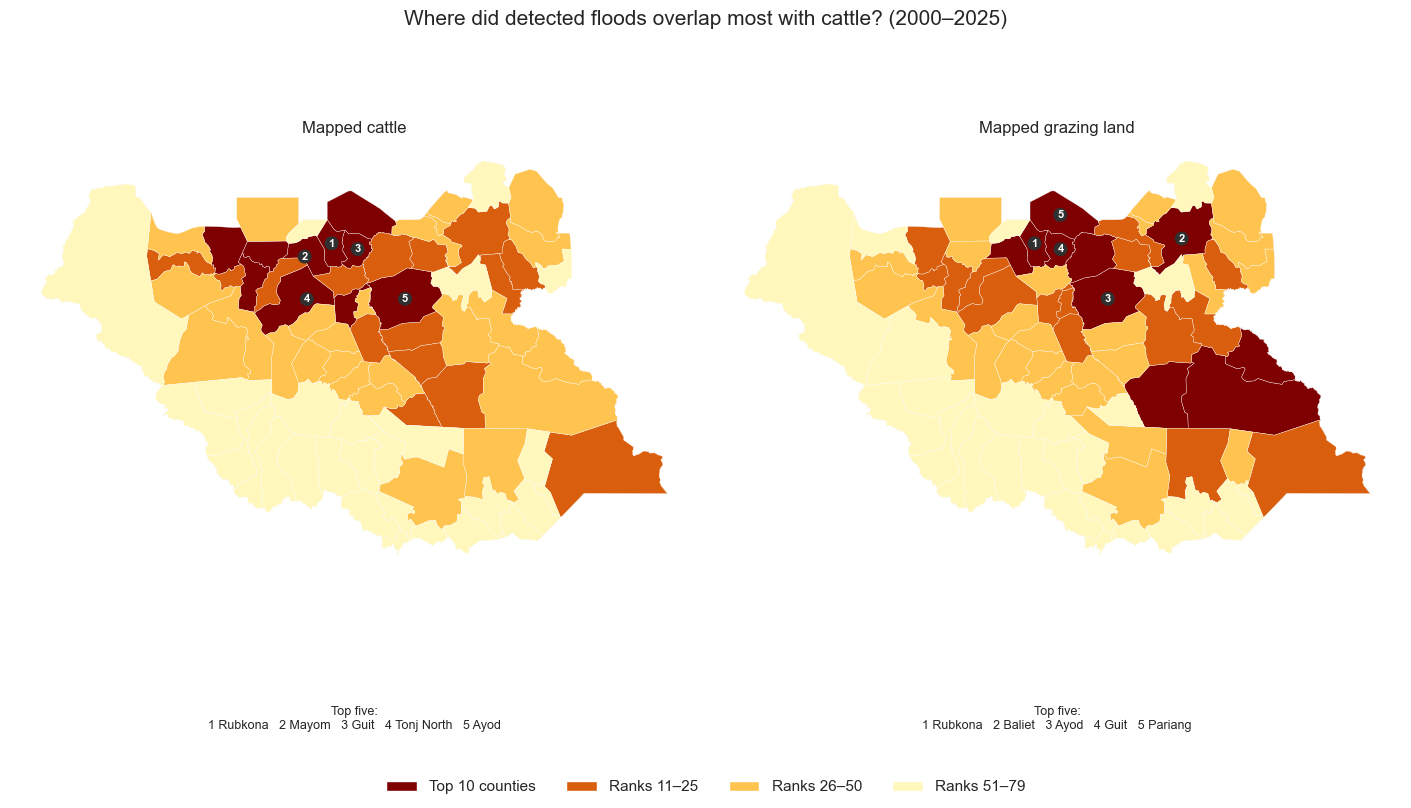

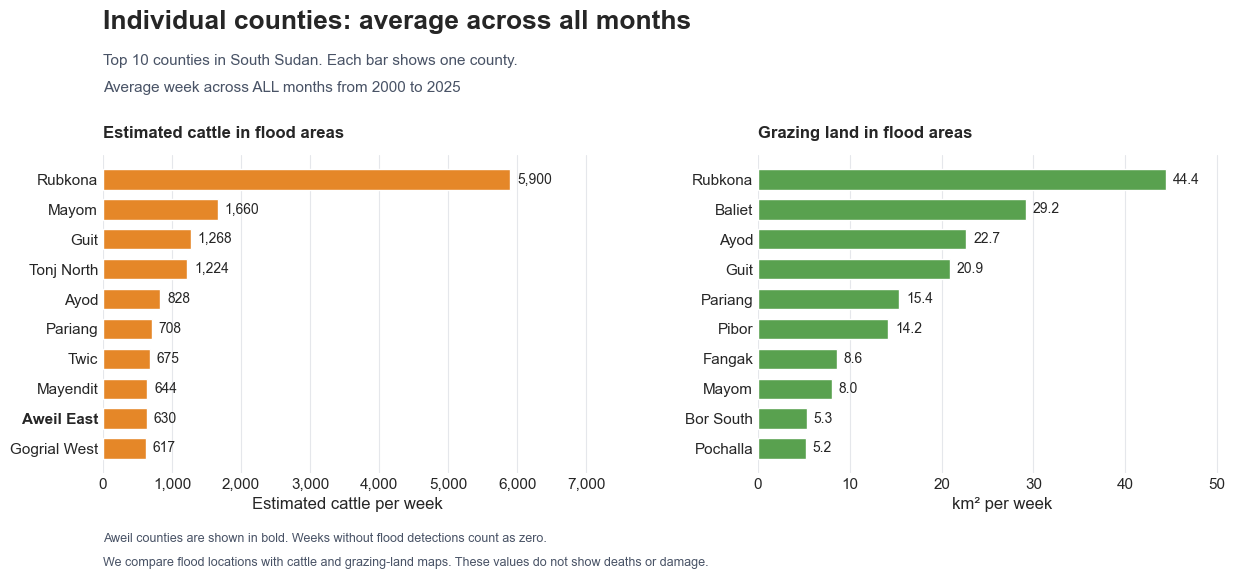

In [6]:
from matplotlib.patches import Patch

map_data = counties.merge(county_summary, on=['state', 'county', 'county_code'], validate='one_to_one')
rank_groups = {
    'Top 10 counties': (1, 10, '#7f0000'),
    'Ranks 11–25': (11, 25, '#d95f0e'),
    'Ranks 26–50': (26, 50, '#fec44f'),
    'Ranks 51–79': (51, 79, '#fff7bc'),
}
map_specs = [
    ('cattle_absolute_rank', 'Mapped cattle'),
    ('rangeland_absolute_rank', 'Mapped grazing land'),
]
fig = plt.figure(figsize=(14, 8), layout='constrained')
grid = fig.add_gridspec(2, 2, height_ratios=[8, 1])
map_axes = [fig.add_subplot(grid[0, column]) for column in range(2)]
key_axes = [fig.add_subplot(grid[1, column]) for column in range(2)]
for plot_number, (rank_column, title) in enumerate(map_specs):
    axis = map_axes[plot_number]
    key_axis = key_axes[plot_number]
    map_data.plot(ax=axis, color='#eeeeee', edgecolor='white', linewidth=0.25)
    for label, (minimum, maximum, colour) in rank_groups.items():
        subset = map_data[map_data[rank_column].between(minimum, maximum)]
        subset.plot(ax=axis, color=colour, edgecolor='white', linewidth=0.25)
    top_five = map_data.nsmallest(5, rank_column).sort_values(rank_column)
    label_points = top_five.geometry.representative_point()
    for number, point in enumerate(label_points, start=1):
        axis.annotate(str(number), (point.x, point.y), ha='center', va='center',
                      fontsize=8, color='white', weight='bold',
                      bbox={'boxstyle': 'circle,pad=0.18', 'facecolor': '#303030', 'edgecolor': 'none'})
    axis.set_title(title)
    axis.set_axis_off()
    key_axis.set_axis_off()
    key_labels = []
    for number, county in enumerate(top_five['county'], start=1):
        key_labels.append(f'{number} {county}')
    top_five_key = '   '.join(key_labels)
    key_axis.text(0.5, 0.6, f'Top five:\n{top_five_key}', ha='center', va='center', fontsize=9)
legend_handles = []
for label, (minimum, maximum, colour) in rank_groups.items():
    legend_handles.append(Patch(facecolor=colour, label=label))
fig.legend(handles=legend_handles, loc='outside lower center', ncol=4, frameon=False)
fig.suptitle('Where did detected floods overlap most with cattle? (2000–2025)', fontsize=15)
fig.savefig(FIGURE_DIR / 'national_county_exposure_maps.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

ranking_specs = [
    ('mean_weekly_potential_cattle_exposed', 'Estimated cattle in flood areas',
     'Estimated cattle per week', '#e58728', ',.0f'),
    ('mean_weekly_flooded_rangeland_km2', 'Grazing land in flood areas',
     'km² per week', '#59a14f', ',.1f'),
]
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.subplots_adjust(left=0.10, right=0.98, bottom=0.20, top=0.73, wspace=0.34)
for plot_number, (column, title, x_label, colour, number_format) in enumerate(ranking_specs):
    axis = axes[plot_number]
    top_ten = county_summary.nlargest(10, column).sort_values(column)
    bars = axis.barh(top_ten['county'], top_ten[column], color=colour, height=0.68)
    for label in axis.get_yticklabels():
        if label.get_text().startswith('Aweil'):
            label.set_weight('bold')
    axis.bar_label(bars, labels=[format(value, number_format) for value in top_ten[column]], padding=5, fontsize=10)
    axis.set_title(title, loc='left', fontsize=12, weight='bold', pad=12)
    axis.set(xlabel=x_label, ylabel='', xlim=(0, top_ten[column].max() * 1.20))
    axis.xaxis.set_major_formatter('{x:,.0f}')
    axis.grid(axis='x', visible=True, color='#e5e7eb', linewidth=0.8)
    axis.grid(axis='y', visible=False)
    axis.tick_params(axis='both', length=0)
    axis.set_axisbelow(True)
    sns.despine(ax=axis, left=True, bottom=True)
fig.text(0.10, 0.94, 'Individual counties: average across all months', fontsize=19, weight='bold', ha='left')
fig.text(0.10, 0.88, 'Top 10 counties in South Sudan. Each bar shows one county.',
         fontsize=11, color='#495366', ha='left')
fig.text(0.10, 0.835, 'Average week across ALL months from 2000 to 2025', fontsize=11, color='#495366')
fig.text(0.10, 0.085, 'Aweil counties are shown in bold. Weeks without flood detections count as zero.',
         fontsize=9, color='#495366')
fig.text(0.10, 0.045, 'We compare flood locations with cattle and grazing-land maps. These values do not show deaths or damage.',
         fontsize=9, color='#495366')
fig.savefig(FIGURE_DIR / 'national_exposure_rankings.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)


## 5. How do the results change through the year?

**Here we add all 79 counties together. Each bar is for the whole country.** We first add up the values for each week. Then we average all January weeks, all February weeks and so on, using 2000 to 2025.

In an average January week, the satellite data shows about **1,623 km² of flood area across South Sudan**. About **698 km² of that area is grazing land according to the land map**. The grazing land is part of the total, so we do not add these two numbers together.

The estimated number of cattle in flood areas is highest in December, at about **38,067 cattle per week across the country**. The cattle map provides this estimate. The satellite does not count the animals.

We assign each week to the month of its Monday. We divide each month's total by its own number of weeks, so longer months do not automatically get higher bars. Weeks without detections count as zero, although the satellite may have missed a flood. Each chart has its own vertical scale.


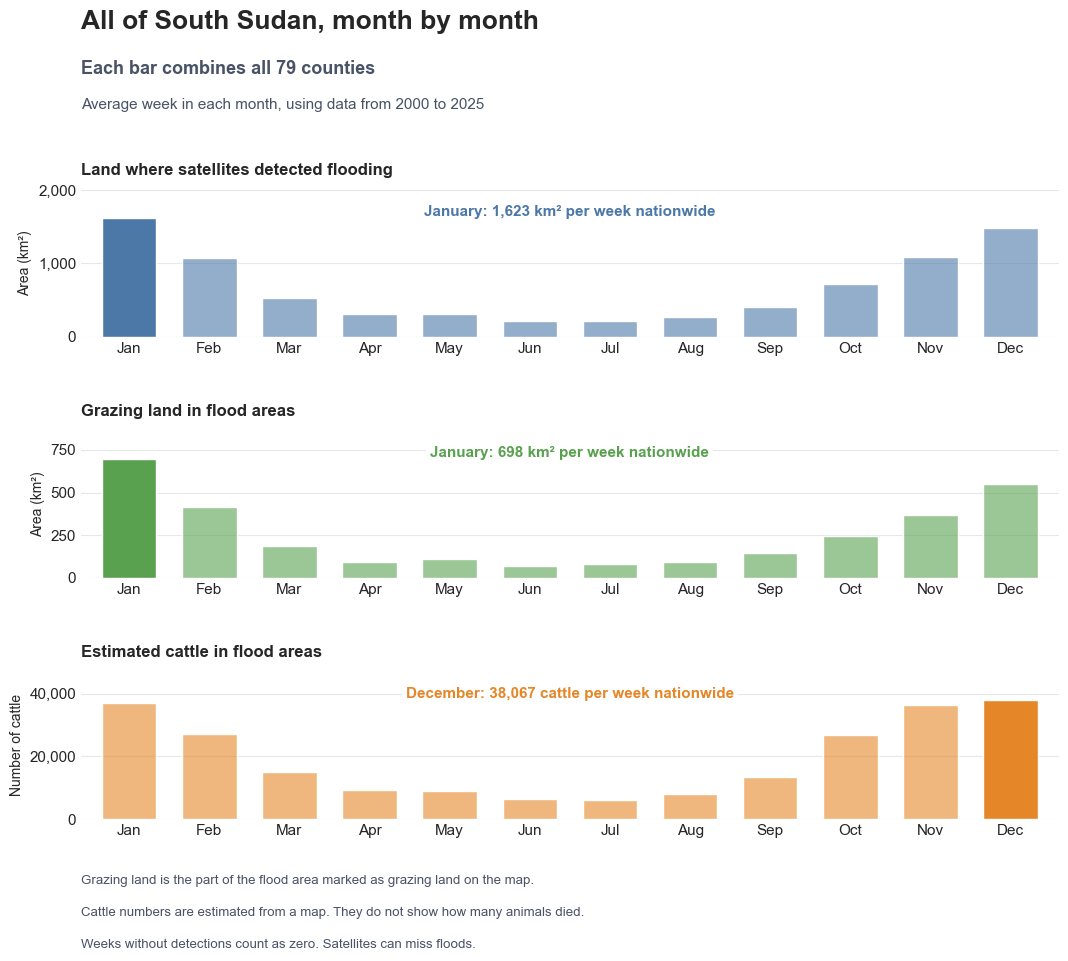

In [7]:
exposure_columns = ['detected_area_km2', 'flooded_rangeland_km2', 'potential_cattle_exposed']
national_weekly = analysis.groupby('week', observed=True)[exposure_columns].sum()
# Include weeks with no detections in the average.
national_weekly = national_weekly.reindex(calendar_weeks, fill_value=0)
# Average each month separately, since some months have more weeks than others.
monthly_exposure = national_weekly.groupby(national_weekly.index.month).mean().reindex(range(1, 13))
monthly_exposure.index.name = 'month'
monthly_exposure['calendar_weeks'] = national_weekly.groupby(national_weekly.index.month).size()
timing = monthly_exposure[exposure_columns].copy()
timing.index = [calendar.month_abbr[month] for month in timing.index]

series = [
    ('detected_area_km2', 'Land where satellites detected flooding', 'km²', '#4c78a8'),
    ('flooded_rangeland_km2', 'Grazing land in flood areas', 'km²', '#59a14f'),
    ('potential_cattle_exposed', 'Estimated cattle in flood areas', 'cattle', '#e58728'),
]
fig, axes = plt.subplots(3, 1, figsize=(11.5, 10))
fig.subplots_adjust(left=0.12, right=0.97, bottom=0.17, top=0.80, hspace=0.63)
for plot_number, (column, title, unit, colour) in enumerate(series):
    axis = axes[plot_number]
    values = monthly_exposure[column]
    peak_month = values.idxmax()
    bar_colours = []
    for month in values.index:
        if month == peak_month:
            bar_colours.append(colour)
        else:
            bar_colours.append(colour + '99')  # Lighter bars outside the peak month.
    axis.bar(values.index, values, color=bar_colours, width=0.68)
    axis.set_title(title, loc='left', fontsize=12, weight='bold', pad=10)
    axis.set(xticks=range(1, 13), xticklabels=timing.index, xlim=(0.4, 12.6), ylim=(0, values.max() * 1.24))
    axis.set_ylabel('Area (km²)' if unit == 'km²' else 'Number of cattle', fontsize=10)
    axis.yaxis.set_major_formatter('{x:,.0f}')
    axis.text(0.5, 0.89, f'{calendar.month_name[peak_month]}: {values.max():,.0f} {unit} per week nationwide',
              transform=axis.transAxes, ha='center', va='top', fontsize=11, color=colour, weight='bold',
              bbox={'facecolor': 'white', 'edgecolor': 'none', 'pad': 3})
    axis.grid(axis='y', visible=True, color='#e5e7eb', linewidth=0.8)
    axis.grid(axis='x', visible=False)
    axis.tick_params(axis='both', length=0)
    axis.set_axisbelow(True)
    sns.despine(ax=axis, left=True, bottom=True)
fig.text(0.12, 0.96, 'All of South Sudan, month by month', fontsize=19, weight='bold')
fig.text(0.12, 0.915, 'Each bar combines all 79 counties', fontsize=13, weight='bold', color='#495366')
fig.text(0.12, 0.88, 'Average week in each month, using data from 2000 to 2025', fontsize=11, color='#495366')
fig.text(0.12, 0.105, 'Grazing land is the part of the flood area marked as grazing land on the map.',
         fontsize=9.5, color='#495366')
fig.text(0.12, 0.073, 'Cattle numbers are estimated from a map. They do not show how many animals died.',
         fontsize=9.5, color='#495366')
fig.text(0.12, 0.041, 'Weeks without detections count as zero. Satellites can miss floods.',
         fontsize=9.5, color='#495366')
fig.savefig(FIGURE_DIR / 'national_exposure_seasonality.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)


## 6. Where were the largest areas and longest series of flood detections?

The left chart shows the longest series of weeks in which flooding was detected somewhere in each county. For example, **279 weeks in Ayod** means there was a detection somewhere in Ayod in each of those weeks. The location can change from week to week. It does not mean the same field stayed under water for 279 weeks.

The right chart shows the **largest detected flood area in a single week for each county**. For Rubkona, that is about **1,992 km²**. We look through all weeks from 2000 to 2025 and take the largest value.

This is different from the previous monthly figure, which shows averages. For example, if three weeks have areas of 100, 200 and 900 km², the largest value is 900 km², but the average is 400 km². A county's largest week can therefore be higher than an average January week for the whole country.

Each chart shows its own top ten counties. The largest areas and the longest series do not have to come from the same flood or the same dates.


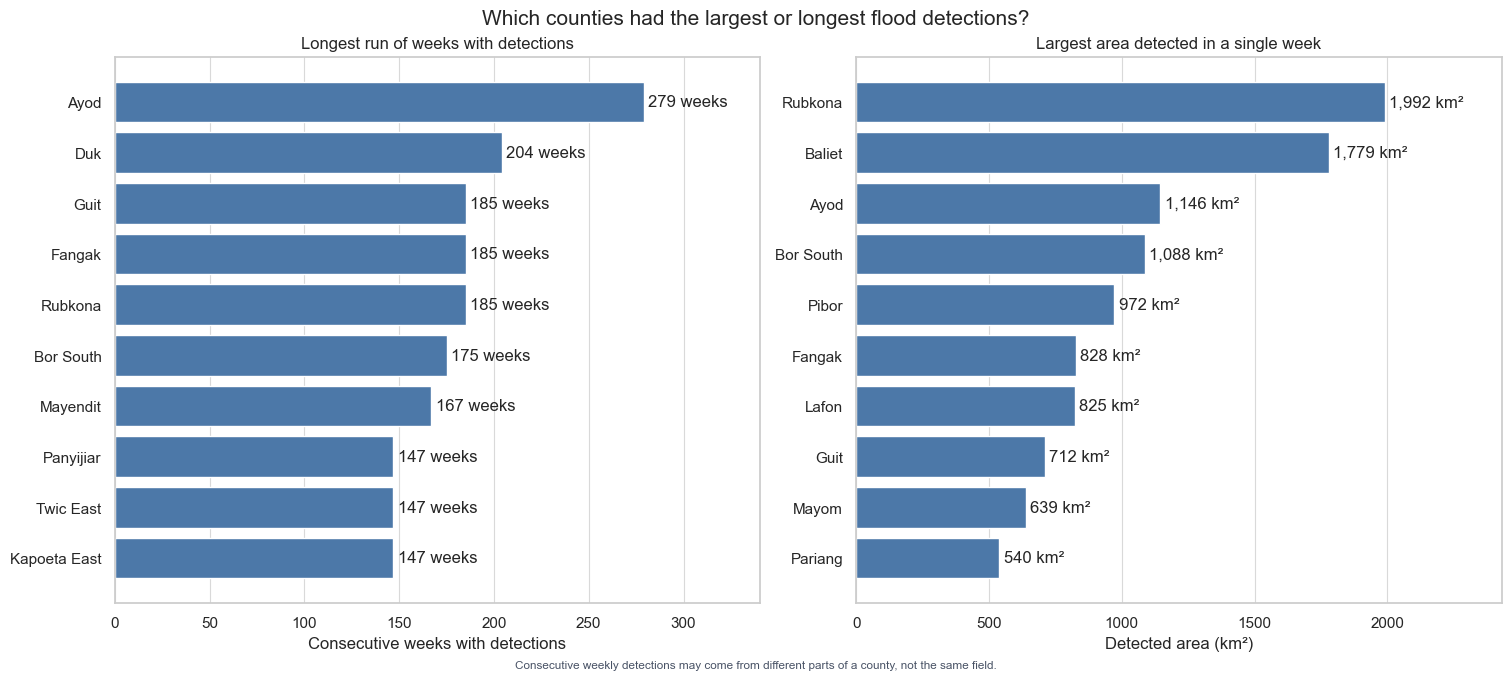

In [8]:
event_input = weekly[['county_code', 'week', 'detected_area_km2']].rename(columns={'county_code': 'county'})
events = find_detected_events(event_input).rename(columns={'county': 'county_code'})
event_exposure = []
for event in events.itertuples(index=False):
    selected = analysis.loc[
        analysis['county_code'].eq(event.county_code)
        & analysis['week'].between(event.start_week, event.end_week)
    ]
    event_exposure.append({
        'potential_cattle_exposure_weeks': selected['potential_cattle_exposed'].sum(),
        'flooded_rangeland_km2_weeks': selected['flooded_rangeland_km2'].sum(),
    })
events = pd.concat([events.reset_index(drop=True), pd.DataFrame(event_exposure)], axis=1)
events = events.merge(baseline[['state', 'county', 'county_code']], on='county_code', validate='many_to_one')

event_summary = events.groupby(['state', 'county'], observed=True).agg(
    longest_detection_sequence=('county_detected_weeks', 'max'),
    largest_weekly_detected_area_km2=('peak_weekly_union_area_km2', 'max'),
).reset_index()
event_specs = [
    ('longest_detection_sequence', 'Longest run of weeks with detections', ' weeks'),
    ('largest_weekly_detected_area_km2', 'Largest area detected in a single week', ' km²'),
]
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), layout='constrained')
for plot_number, (column, title, unit) in enumerate(event_specs):
    axis = axes[plot_number]
    top_ten = event_summary.nlargest(10, column).sort_values(column)
    colours = []
    for county in top_ten['county']:
        if county.startswith('Aweil'):
            colours.append('#f28e2b')
        else:
            colours.append('#4c78a8')
    bars = axis.barh(top_ten['county'], top_ten[column], color=colours)
    axis.bar_label(bars, labels=[f'{value:,.0f}{unit}' for value in top_ten[column]], padding=3)
    x_label = 'Consecutive weeks with detections' if column == 'longest_detection_sequence' else 'Detected area (km²)'
    axis.set(title=title, xlabel=x_label, ylabel='')
    axis.set_xlim(0, top_ten[column].max() * 1.22)
    axis.grid(axis='x', visible=True, color='#d9d9d9', linewidth=0.8)
    axis.grid(axis='y', visible=False)
    axis.set_axisbelow(True)
fig.suptitle('Which counties had the largest or longest flood detections?', fontsize=15)
fig.text(0.5, -0.02, 'Consecutive weekly detections may come from different parts of a county, not the same field.', ha='center', fontsize=8.5, color='#495366')
fig.savefig(FIGURE_DIR / 'national_size_duration_exposure.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

## 7. How does Aweil compare with the rest of South Sudan?

We now look at the five Aweil counties. We compare their rankings and how much cattle and grazing land they have according to the maps.

A county with more cattle can have a higher number in flood areas simply because its herd is larger. We therefore also compare the results with each county's total cattle estimate.

The calculation below adds up the weekly cattle estimates in flood areas, divides by the county's mapped cattle total, and then divides by the number of years. This gives a comparison score expressed in weeks per year. A score of 1 is the same total as counting the whole mapped herd for one week each year. It could also come from counting half the herd for two weeks. It does not tell us how long individual animals were in floodwater.


In [9]:
aweil = county_summary.loc[
    county_summary['state'].eq('Northern Bahr el Ghazal')
    & county_summary['county'].str.startswith('Aweil')
].sort_values('cattle_absolute_rank')
display(aweil[[
    'county', 'mapped_cattle', 'mapped_rangeland_km2', 'potential_cattle_weeks',
    'cattle_absolute_rank', 'flooded_rangeland_km2_weeks', 'rangeland_absolute_rank',
    'largest_weekly_flood_area_km2',
]].round(2))
national_median = county_summary['cattle_exposure_weeks_per_year'].median()
display(Markdown(
    f"Using the comparison score explained above, the five Aweil counties range from "
    f"**{aweil['cattle_exposure_weeks_per_year'].min():.2f}** to "
    f"**{aweil['cattle_exposure_weeks_per_year'].max():.2f} weeks per year**. "
    f"The middle value among counties across South Sudan is **{national_median:.2f} weeks per year**."
))

,county,mapped_cattle,mapped_rangeland_km2,potential_cattle_weeks,cattle_absolute_rank,flooded_rangeland_km2_weeks,rangeland_absolute_rank,largest_weekly_flood_area_km2
35,Aweil East,505027.78,4349.46,855560.34,9,5165.05,16,375.26
37,Aweil South,141256.80,1488.71,447909.62,16,3484.21,25,169.81
38,Aweil West,318964.95,3606.96,168182.02,25,1056.36,36,91.06
36,Aweil North,463800.50,4454.18,41172.03,39,252.69,53,42.85
34,Aweil Centre,364961.83,6375.80,32947.69,43,731.91,42,93.65


Using the comparison score explained above, the five Aweil counties range from **0.00** to **0.12 weeks per year**. The middle value among counties across South Sudan is **0.01 weeks per year**.

## 8. What did we find?

The points below summarise the results. They describe the supplied data and map-based estimates.


In [10]:
top_cattle = county_summary.nlargest(1, 'potential_cattle_weeks').iloc[0]
top_rangeland = county_summary.nlargest(1, 'flooded_rangeland_km2_weeks').iloc[0]
flood_peak_month = timing['detected_area_km2'].idxmax()
cattle_peak_month = timing['potential_cattle_exposed'].idxmax()
aweil_absolute = aweil.nsmallest(1, 'cattle_absolute_rank').iloc[0]
aweil_relative = aweil.nlargest(1, 'cattle_exposure_weeks_per_year').iloc[0]
display(Markdown(
    f"- **{top_cattle['county']} ({top_cattle['state']})** has the highest average number of "
    f"estimated cattle in flood areas per week. **{top_rangeland['county']} ({top_rangeland['state']})** "
    f"has the highest average grazing area in flood areas per week.\n"
    f"- Across South Sudan, the average weekly detected flood area is highest in **{flood_peak_month}**. "
    f"The estimated number of cattle in flood areas is highest in **{cattle_peak_month}**. "
    f"We still need to check this pattern against local knowledge and how often the satellite could see the area.\n"
    f"- Of the five Aweil counties, **{aweil_absolute['county']}** has the highest average number of "
    f"cattle in flood areas. It ranks **{int(aweil_absolute['cattle_absolute_rank'])}** in the country. "
    f"**{aweil_relative['county']}** stands out most when we compare the results with each county's "
    f"own total number of cattle on the map.\n"
    f"- We found **{len(events):,} series of consecutive weeks with flood detections within a county**. "
    f"The longest series lasts **{int(events['county_detected_weeks'].max())} weeks**. "
    f"The detected location can change each week, so this does not mean one field was flooded for that whole time."
))


- **Rubkona (Unity)** has the highest average number of estimated cattle in flood areas per week. **Rubkona (Unity)** has the highest average grazing area in flood areas per week.
- Across South Sudan, the average weekly detected flood area is highest in **Jan**. The estimated number of cattle in flood areas is highest in **Dec**. We still need to check this pattern against local knowledge and how often the satellite could see the area.
- Of the five Aweil counties, **Aweil East** has the highest average number of cattle in flood areas. It ranks **9** in the country. **Aweil South** stands out most when we compare the results with each county's own total number of cattle on the map.
- We found **8,476 series of consecutive weeks with flood detections within a county**. The longest series lasts **279 weeks**. The detected location can change each week, so this does not mean one field was flooded for that whole time.

## 9. What should we keep in mind?

- Satellites can miss floods. No detection does not always mean dry land.
- The cattle map is a fixed estimate. Animals move, and the map does not show their actual locations in each week.
- We assume cattle are spread evenly within each large square on the cattle map. The squares are about 9 km across, so this is a rough estimate.
- The cattle map does not include goats or sheep, which also matter for people's livelihoods.
- The grazing-land map does not show how land use changed over the years.
- Flooding can damage land or make it harder to reach. It can also bring water and help grass grow later. Our figures do not measure these effects.
- County averages can hide differences between villages and groups of people. Some herders can move their animals, while others may be unable to move because of conflict or other problems.
- The labels `recurring` and `unusual` describe how often flooding occurs, not how damaging it is. Before using them to predict floods, we need to check that they do not include information from after the date we want to predict.

These results can help us decide what to investigate next. They need local knowledge before they can be used to make decisions about support.


## 10. Save the results

We save the tables as CSV files in `outputs/national/tables/`. The figures are saved in `outputs/national/figures/`. Running the notebook again recreates these files from the supplied data.


In [11]:
tables = {
    'national_weekly_floods.csv': weekly,
    'national_weekly_floods_by_type.csv': weekly_by_type,
    'national_weekly_exposure.csv': weekly_exposure,
    'national_monthly_exposure.csv': monthly_exposure.reset_index(),
    'national_annual_detection_coverage.csv': annual_coverage,
    'national_county_exposure_baseline.csv': baseline,
    'national_county_exposure_summary.csv': county_summary,
    'national_detection_runs.csv': events,
}
for filename, table in tables.items():
    table.to_csv(TABLE_DIR / filename, index=False)
print(f'Saved {len(tables)} tables to {TABLE_DIR}')
print(f'Saved 4 figures to {FIGURE_DIR}')

Saved 8 tables to C:\Users\ezzam\Desktop\Capstone Data Challenge\JBG060_ZHL_2026\EDA_flood_masks\outputs\national\tables
Saved 4 figures to C:\Users\ezzam\Desktop\Capstone Data Challenge\JBG060_ZHL_2026\EDA_flood_masks\outputs\national\figures
